In [ ]:
# Installation des paquets directement depuis le Notebook
!pip install sqlite3 matplotlib tabulate pyogrio folium mapclassify plotly

In [24]:
import geopandas as gpd
gdf = gpd.read_file("../data/SWISS.gpkg")
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 409276 entries, 0 to 409275
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   uuid                    409276 non-null  str           
 1   datum_aenderung         409276 non-null  datetime64[ms]
 2   datum_erstellung        407567 non-null  datetime64[ms]
 3   erstellung_jahr         409251 non-null  float64       
 4   erstellung_monat        318183 non-null  float64       
 5   grund_aenderung         409276 non-null  str           
 6   herkunft                409276 non-null  str           
 7   herkunft_jahr           409276 non-null  int32         
 8   herkunft_monat          409245 non-null  float64       
 9   objektart               409276 non-null  str           
 10  revision_jahr           409249 non-null  float64       
 11  revision_monat          409249 non-null  float64       
 12  revision_qualitaet    

<Axes: >

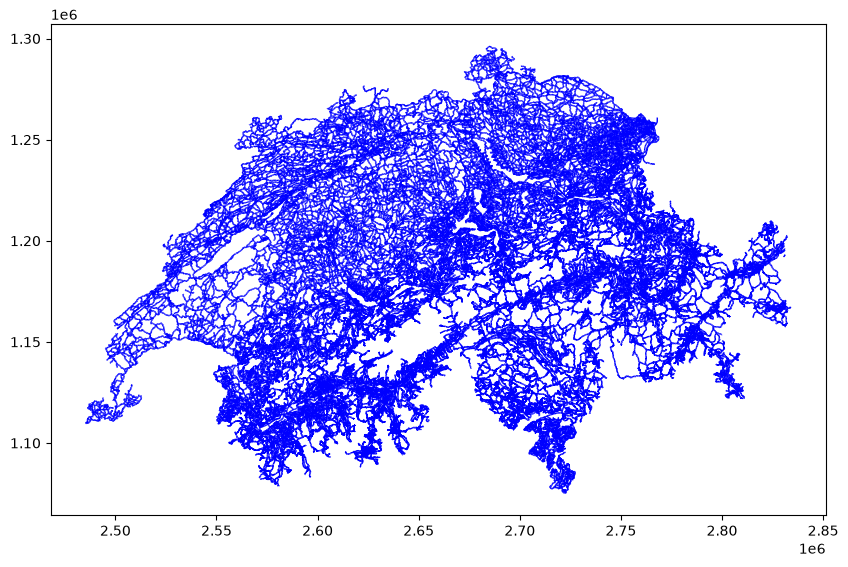

In [25]:
gdf.plot(figsize=(10, 10), linewidth=1, color='blue')

In [26]:
gdf_aleatoire = gdf.sample(n=100, random_state=42)
gdf_aleatoire.head()

,uuid,datum_aenderung,datum_erstellung,erstellung_jahr,erstellung_monat,grund_aenderung,herkunft,herkunft_jahr,herkunft_monat,objektart,...,richtungsgetrennt,tlm_strassen_name_uuid,name,belagsart,kreisel,verkehrsbeschraenkung,eigentuemer,verkehrsbedeutung,strassenname,geometry
286331,{9CF11D13-2968-4CA2-8810-8CDB715B8834},2021-05-19,2007-09-20,2002.0,NaN,Verbessert,swisstopo,2019,6.0,4m Strasse,...,Falsch,NaN,NaN,Hart,Falsch,Keine,ub,k_W,Eggstrasse,"LINESTRING Z (2708357.084 1240423.961 783.763,..."
190530,{B33AA20E-C7F8-4095-933F-ED3E8265DB64},2020-03-24,NaT,2003.0,NaN,Verbessert,swisstopo,2019,6.0,4m Strasse,...,Falsch,NaN,NaN,Hart,Falsch,Keine,ub,k_W,Schlattstrasse,"LINESTRING Z (2730523.75 1204868.82 831.81, 27..."
359552,{55DB90D9-8995-4282-B40F-282B5C8A270F},2025-03-14,2018-12-06,2016.0,6.0,Verbessert,swisstopo,2024,6.0,1m Weg,...,k_W,NaN,NaN,Hart,k_W,Keine,k_W,k_W,NaN,LINESTRING Z (2658000.855 1177383.469 1196.681...
165454,{F30687E5-332F-4F57-8A73-392639405295},2025-06-24,2009-04-27,2006.0,4.0,Verbessert,swisstopo,2024,6.0,2m Weg,...,Falsch,NaN,NaN,Natur,k_W,Keine,k_W,k_W,NaN,"LINESTRING Z (2646735.28 1183887.104 1314.96, ..."
10646,{209107F9-EB5F-454A-A962-5514CD38A2F4},2024-04-11,2007-09-20,2003.0,NaN,Verbessert,swisstopo,2021,6.0,2m Weg,...,Falsch,NaN,NaN,Natur,k_W,Keine,k_W,k_W,Alpstrasse,"LINESTRING Z (2772712.288 1199494.938 984.261,..."


<Axes: >

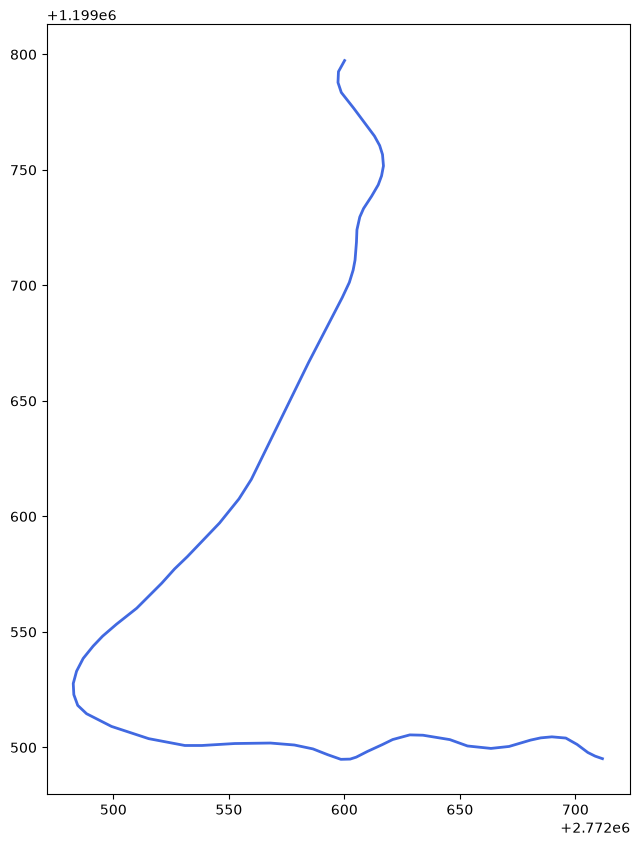

In [27]:
uuid = '{209107F9-EB5F-454A-A962-5514CD38A2F4}' 
one_path = gdf[gdf['uuid'] == uuid]
one_path.plot(figsize=(10, 10), color='royalblue', linewidth=2)

In [28]:
import plotly.graph_objects as go

geometrie = one_path.geometry.iloc[0]

x_coords = [p[0] for p in geometrie.coords]
y_coords = [p[1] for p in geometrie.coords]
z_coords = [p[2] for p in geometrie.coords]

fig = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    mode='lines+markers',
    line=dict(color='royalblue', width=5),
    marker=dict(size=3, color='orange')
)])

# Afficher le plan 3D interactif
fig.show()


In [29]:
import geopandas as gpd
ddf = gpd.read_file("../data/transports.csv")
ddf.info()

<class 'pandas.DataFrame'>
RangeIndex: 62275 entries, 0 to 62274
Data columns (total 34 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   sloid                                           62275 non-null  str  
 1   numberShort                                     62275 non-null  str  
 2   uicCountryCode                                  62275 non-null  str  
 3   number                                          62275 non-null  str  
 4   checkDigit                                      62275 non-null  str  
 5   validFrom                                       62275 non-null  str  
 6   validTo                                         62275 non-null  str  
 7   designation                                     62275 non-null  str  
 8   designationOperational                          62275 non-null  str  
 9   length                                          62275 non-null  str  
 1

In [30]:
ddf_aleatoire = ddf.sample(n=100, random_state=42)
ddf_aleatoire.head()

,sloid,numberShort,uicCountryCode,number,checkDigit,validFrom,validTo,designation,designationOperational,length,...,servicePointBusinessOrganisationNumber,servicePointBusinessOrganisationAbbreviationDe,servicePointBusinessOrganisationAbbreviationFr,servicePointBusinessOrganisationAbbreviationIt,servicePointBusinessOrganisationAbbreviationEn,servicePointBusinessOrganisationDescriptionDe,servicePointBusinessOrganisationDescriptionFr,servicePointBusinessOrganisationDescriptionIt,servicePointBusinessOrganisationDescriptionEn,status
20088,ch:1:sloid:72104:0:770359,72104,85,8572104,3,2026-03-27,9999-12-31,,02,,...,801,PAG,PAG,PAG,PAG,PostAuto AG,CarPostal SA,AutoPostale SA,PostBus Ltd,VALIDATED
54840,ch:1:sloid:93985:0:2,93985,85,8593985,0,2026-03-27,9999-12-31,,02,19.0,...,876,VMCV,VMCV,VMCV,VMCV,Transports publics Vevey-Montreux-Chillon-Vill...,Transports publics Vevey-Montreux-Chillon-Vill...,Transports publics Vevey-Montreux-Chillon-Vill...,Transports publics Vevey-Montreux-Chillon-Vill...,VALIDATED
61159,ch:1:sloid:9250:0:49678,9250,85,8509250,2,2026-03-27,9999-12-31,2,02,234.0,...,72,RhB,RhB,RhB,RhB,Rhätische Bahn,Rhätische Bahn,Rhätische Bahn,Rhätische Bahn,VALIDATED
49572,ch:1:sloid:91323:3,91323,85,8591323,6,2023-11-23,9999-12-31,Bus Ri BUCH/BWIP,,,...,849,VBZ,VBZ,VBZ,VBZ,Verkehrsbetriebe Zürich,Verkehrsbetriebe Zürich,Verkehrsbetriebe Zürich,Verkehrsbetriebe Zürich,VALIDATED
40859,ch:1:sloid:87356:0:15126,87356,85,8587356,2,2026-03-27,9999-12-31,,01,18.0,...,834,TPF Auto,TPF Auto,TPF Auto,TPF Auto,Service d'automobiles TPF,Service d'automobiles TPF,Service d'automobiles TPF,Service d'automobiles TPF,VALIDATED


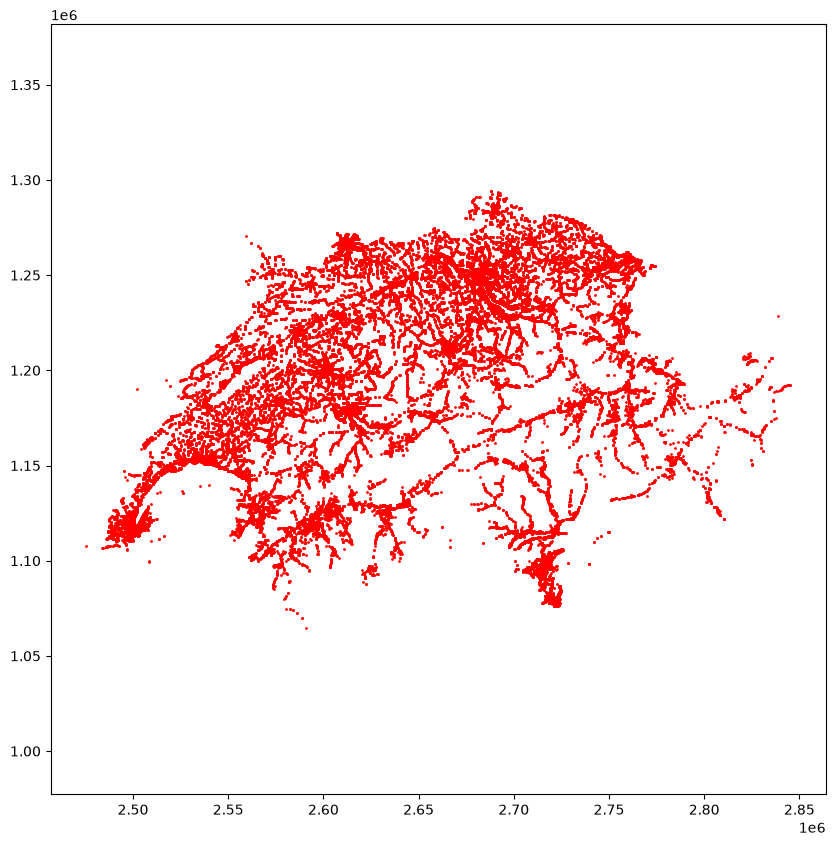

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

x = pd.to_numeric(ddf["lv95East"], errors="coerce")
y = pd.to_numeric(ddf["lv95North"], errors="coerce")

plt.figure(figsize=(10, 10))
plt.scatter(x, y, s=1, color="red")
plt.axis("equal")
plt.show()

In [33]:
import pandas as pd

t = pd.DataFrame(gdf[["uuid", "wanderwege", "objektart", "belagsart"]].sample(4, random_state=1))
t["geometry"] = gdf.loc[t.index, "geometry"].astype(str).str[:60] + "…"
print(t.to_markdown(index=False))

s = ddf[ddf["uicCountryCode"].astype(str) == "85"]
s = s[["designationOfficial", "lv95East", "lv95North", "height", "uicCountryCode"]].sample(4, random_state=1)
print(s.to_markdown(index=False, floatfmt=".1f"))

| uuid                                   | wanderwege   | objektart      | belagsart   | geometry                                                      |
|:---------------------------------------|:-------------|:---------------|:------------|:--------------------------------------------------------------|
| {579B1CED-A0E7-4822-8176-15FCCC599584} | Wanderweg    | 3m Strasse     | Hart        | LINESTRING Z (2733196.966 1124595.195008 327.766, 2733196.49… |
| {99723204-7184-49E5-BCB1-33F4DF6B36DE} | Wanderweg    | Markierte Spur | k_W         | LINESTRING Z (2649034.050001 1205933.323827 876.312, 2649040… |
| {67CFA3B2-1E89-4CF7-8CE0-2FE7E1894161} | Wanderweg    | 4m Strasse     | Hart        | LINESTRING Z (2632948.242 1166916.728003 597.922, 2632942.35… |
| {19AE62E9-A3F2-42AA-BB77-9864D424202C} | Wanderweg    | 4m Strasse     | Hart        | LINESTRING Z (2689383.021 1246142.787996 643.166, 2689379.20… |
| designationOfficial            |   lv95East |   lv95North |   height |   uicCoun